<a href="https://colab.research.google.com/github/kestrel677/Supervised-Machine-learning-/blob/main/XGBoost_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier

In [42]:
# Loading the data
df = pd.read_csv('/content/fraud_data.csv')
df.head()

,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud
0,04-01-2019 00:58,"""Stokes, Christiansen and Sipes""",grocery_net,14.37,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",09-11-1939,a3806e984cec6ac0096d8184c64ad3a1,65.654142,-164.722603,1
1,04-01-2019 15:06,Predovic Inc,shopping_net,966.11,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",09-11-1939,a59185fe1b9ccf21323f581d7477573f,65.468863,-165.473127,1
2,04-01-2019 22:37,Wisozk and Sons,misc_pos,49.61,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",09-11-1939,86ba3a888b42cd3925881fa34177b4e0,65.347667,-165.914542,1
3,04-01-2019 23:06,Murray-Smitham,grocery_pos,295.26,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",09-11-1939,3a068fe1d856f0ecedbed33e4b5f4496,64.445035,-166.080207,1
4,04-01-2019 23:59,Friesen Lt,health_fitness,18.17,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",09-11-1939,891cdd1191028759dc20dc224347a0ff,65.447094,-165.446843,1


In [43]:
df.shape

(14446, 15)

In [44]:
df.columns


Index(['trans_date_trans_time', 'merchant', 'category', 'amt', 'city', 'state',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'merch_lat',
       'merch_long', 'is_fraud'],
      dtype='object')

In [45]:
df.dtypes

,0
trans_date_trans_time,object
merchant,object
category,object
amt,float64
city,object
state,object
lat,float64
long,float64
city_pop,int64
job,object


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14446 entries, 0 to 14445
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   trans_date_trans_time  14446 non-null  object 
 1   merchant               14446 non-null  object 
 2   category               14446 non-null  object 
 3   amt                    14446 non-null  float64
 4   city                   14446 non-null  object 
 5   state                  14446 non-null  object 
 6   lat                    14446 non-null  float64
 7   long                   14446 non-null  float64
 8   city_pop               14446 non-null  int64  
 9   job                    14446 non-null  object 
 10  dob                    14446 non-null  object 
 11  trans_num              14446 non-null  object 
 12  merch_lat              14446 non-null  float64
 13  merch_long             14446 non-null  float64
 14  is_fraud               14446 non-null  object 
dtypes:

In [47]:
df.describe()

,amt,lat,long,city_pop,merch_lat,merch_long
count,14446.000000,14446.000000,14446.000000,1.444600e+04,14446.000000,14446.000000
mean,124.430073,39.787692,-110.874225,1.065370e+05,39.787991,-110.874892
std,231.352587,5.317039,12.985813,2.902916e+05,5.360593,12.995596
min,1.000000,20.027100,-165.672300,4.600000e+01,19.032689,-166.670685
25%,12.080000,36.715400,-120.415800,4.930000e+02,36.794655,-120.146253
50%,51.520000,39.666200,-111.098500,1.645000e+03,39.620953,-111.192629
75%,101.030000,41.940400,-101.136000,3.543900e+04,42.275740,-100.446822
max,3261.470000,66.693300,-89.628700,2.383912e+06,67.510267,-88.646366


In [48]:
df.isnull().sum()

,0
trans_date_trans_time,0
merchant,0
category,0
amt,0
city,0
state,0
lat,0
long,0
city_pop,0
job,0


In [49]:
df.duplicated().sum()

np.int64(63)

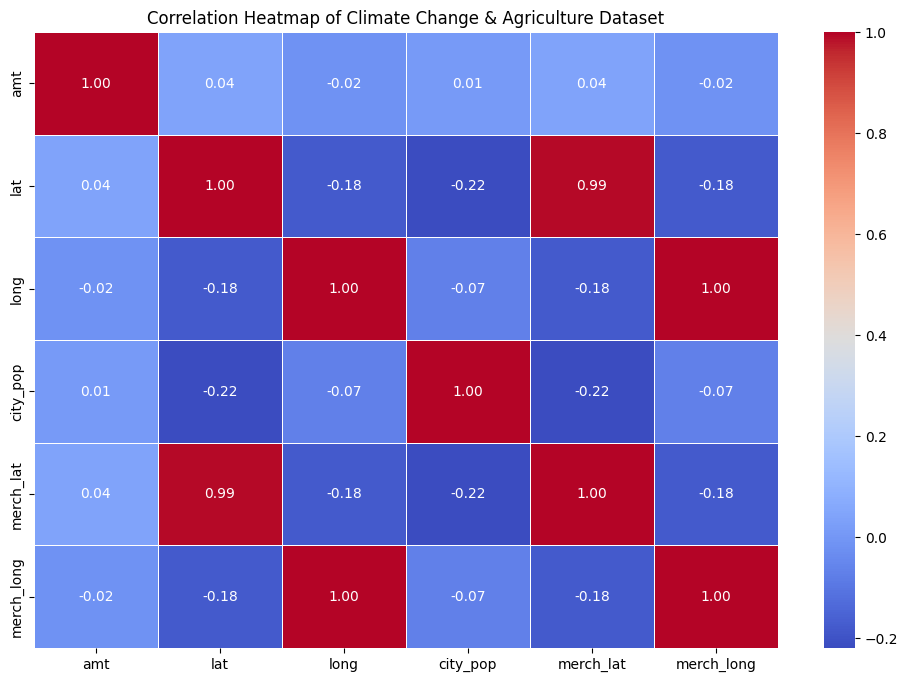

In [50]:
#Using  heatmap in data visulization to find relationship between all numerical variables with eachother.
plt.figure(figsize=(12,8))
corr = df.select_dtypes(include=['int64','float64']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap of Climate Change & Agriculture Dataset")
plt.show()

In [51]:
df['is_fraud'] = pd.to_numeric(df['is_fraud'], errors='coerce')
df = df.dropna(subset=['is_fraud'])
df['is_fraud'] = df['is_fraud'].astype(int)

In [52]:
df['is_fraud'].value_counts()

,count
is_fraud,
0,12600
1,1844


In [53]:
import pandas as pd
import numpy as np


df['is_fraud'] = pd.to_numeric(df['is_fraud'], errors='coerce')
df = df.dropna(subset=['is_fraud'])
df['is_fraud'] = df['is_fraud'].astype(int)

df = df.drop(['trans_date_trans_time', 'trans_num'], axis=1)

df['dob'] = pd.to_datetime(df['dob'], dayfirst=True, errors='coerce')
df = df.dropna(subset=['dob'])

current_year = 2026
df['age'] = current_year - df['dob'].dt.year
df = df.drop('dob', axis=1)
df = df.drop(['merchant', 'city', 'job'], axis=1)

In [54]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Encode Category and State
df['category'] = le.fit_transform(df['category'])
df['state'] = le.fit_transform(df['state'])

print("Categorical columns encoded successfully.")

Categorical columns encoded successfully.


In [57]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Encode the remaining text columns into numbers
df['category'] = le.fit_transform(df['category'])
df['state'] = le.fit_transform(df['state'])

print("Categorical encoding for 'category' and 'state' is done.")

Categorical encoding for 'category' and 'state' is done.


In [58]:
from sklearn.model_selection import train_test_split

X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [61]:
from xgboost import XGBClassifier

# Initialize the model
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric='logloss'
)

# Fit the model
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [62]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Predictions
y_pred = xgb_model.predict(X_test)
y_probs = xgb_model.predict_proba(X_test)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print(f"\nROC-AUC Score: {roc_auc_score(y_test, y_probs):.4f}")

Confusion Matrix:
[[2497   23]
 [  66  303]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      2520
           1       0.93      0.82      0.87       369

    accuracy                           0.97      2889
   macro avg       0.95      0.91      0.93      2889
weighted avg       0.97      0.97      0.97      2889


ROC-AUC Score: 0.9902


In [63]:
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross validation
cv_results = cross_val_score(xgb_model, X_train, y_train, cv=5)

print(f"Cross-Validation Accuracy: {cv_results.mean():.4f} (+/- {cv_results.std():.4f})")

Cross-Validation Accuracy: 0.9729 (+/- 0.0030)


In [64]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import joblib

# Build the pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', xgb_model)
])

# Fit the pipeline on the training data
pipeline.fit(X_train, y_train)

# Save the pipeline as a file
joblib.dump(pipeline, 'fraud_detection_model.pkl')

print("Pipeline created and saved as 'fraud_detection_model.pkl'.")

Pipeline created and saved as 'fraud_detection_model.pkl'.
